In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
df_path = "../data/processed/cleaned_dataset.csv"
df = pd.read_csv(df_path)

Summary Statistics

In [159]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (1200, 12)


In [160]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             1200 non-null   int64  
 1   customer_id                1200 non-null   int64  
 2   transaction_datetime       1200 non-null   object 
 3   country                    1200 non-null   object 
 4   channel                    1200 non-null   object 
 5   merchant_category          1200 non-null   object 
 6   amount                     1200 non-null   float64
 7   device_trust_score         1200 non-null   float64
 8   num_txn_24h_customer       1200 non-null   int64  
 9   previous_chargeback_count  1200 non-null   int64  
 10  is_fraud                   1200 non-null   int64  
 11  transaction_note           1200 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 112.6+ KB
None


In [161]:
print("\nDescriptive Statistic:")
print(df.describe())


Descriptive Statistic:
       transaction_id  customer_id       amount  device_trust_score  \
count     1200.000000  1200.000000  1200.000000         1200.000000   
mean       600.500000  1090.850000  2592.431525           52.600000   
std        346.554469    51.657603  1634.231457           24.731013   
min          1.000000  1000.000000     4.600000            0.000000   
25%        300.750000  1046.000000  1300.060000           31.000000   
50%        600.500000  1091.000000  2520.040000           52.000000   
75%        900.250000  1134.000000  3753.340000           74.000000   
max       1200.000000  1179.000000  9984.420000          100.000000   

       num_txn_24h_customer  previous_chargeback_count     is_fraud  
count           1200.000000                1200.000000  1200.000000  
mean               3.108333                   1.733333     0.067500  
std                2.898896                   1.618973     0.250991  
min                0.000000                   0.000000  

In [162]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)

print(missing[missing > 0].to_frame("Count of missing values"))


Empty DataFrame
Columns: [Count of missing values]
Index: []


Distribution of Target Variable

is_fraud
0    1119
1      81
Name: count, dtype: int64


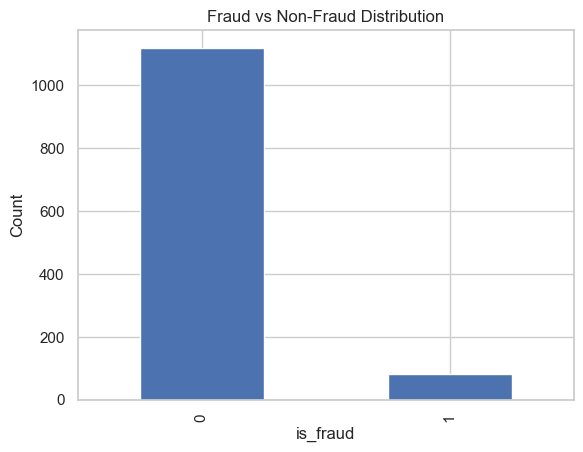

Fraud rate: 0.0675


In [163]:
# Check target variable distribution (balance/imbalance)
fraud_counts = df["is_fraud"].value_counts()

print(fraud_counts)

plt.figure()
fraud_counts.plot(kind="bar")
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.show()

print("Fraud rate:", df["is_fraud"].mean())


In [164]:
numeric_cols = ["amount", "device_trust_score", "num_txn_24h_customer", "previous_chargeback_count"]
categorical_cols = ["country", "channel", "merchant_category"]

Distribution of Numerical Features

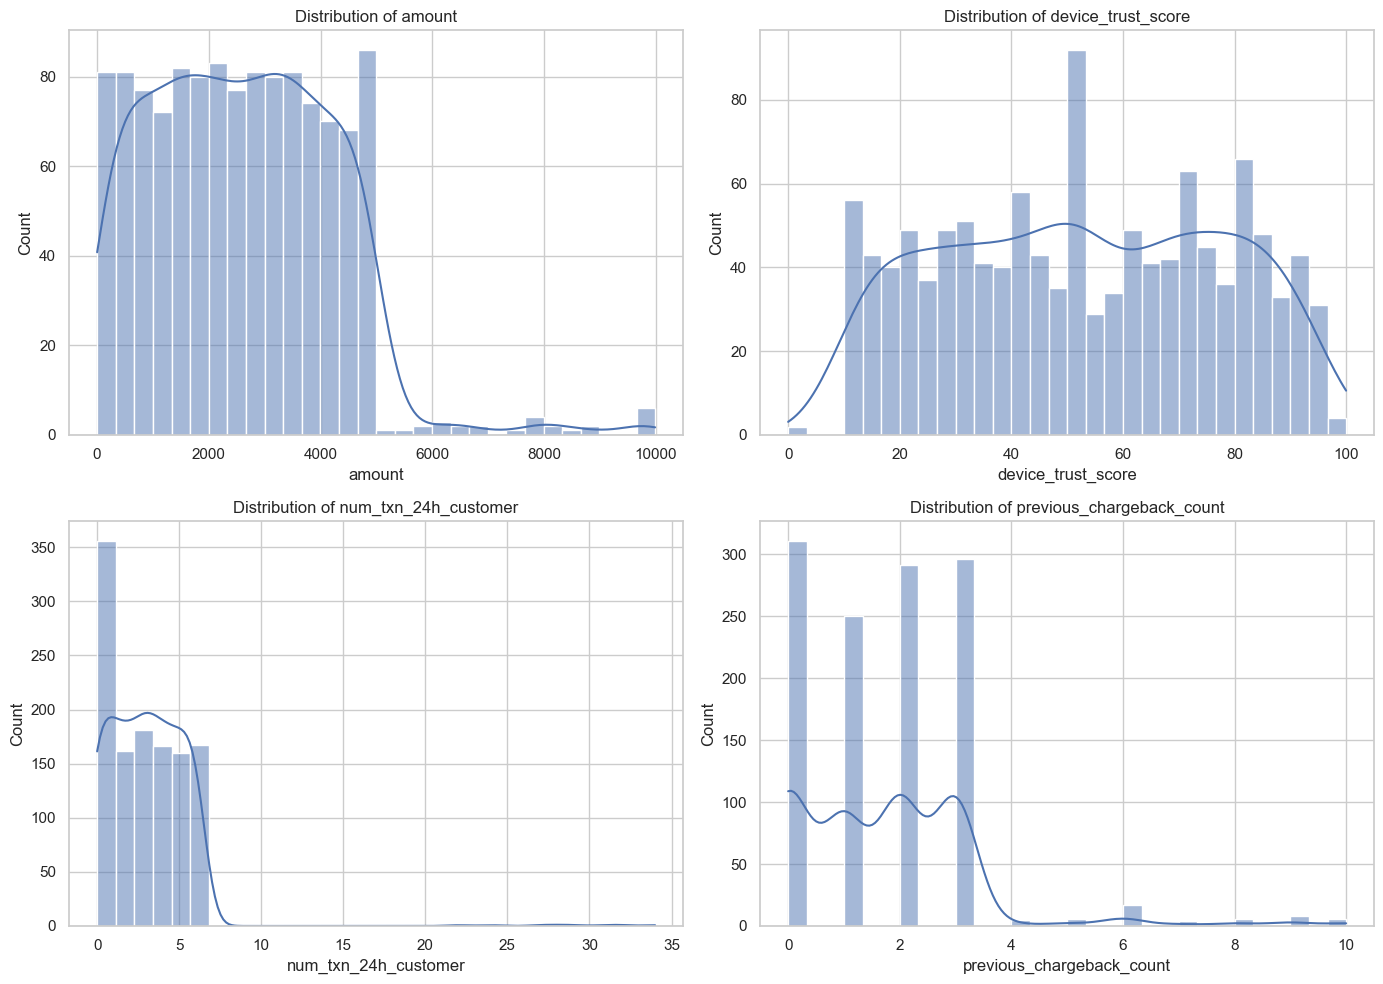

In [165]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


Distribution of Categorical Features

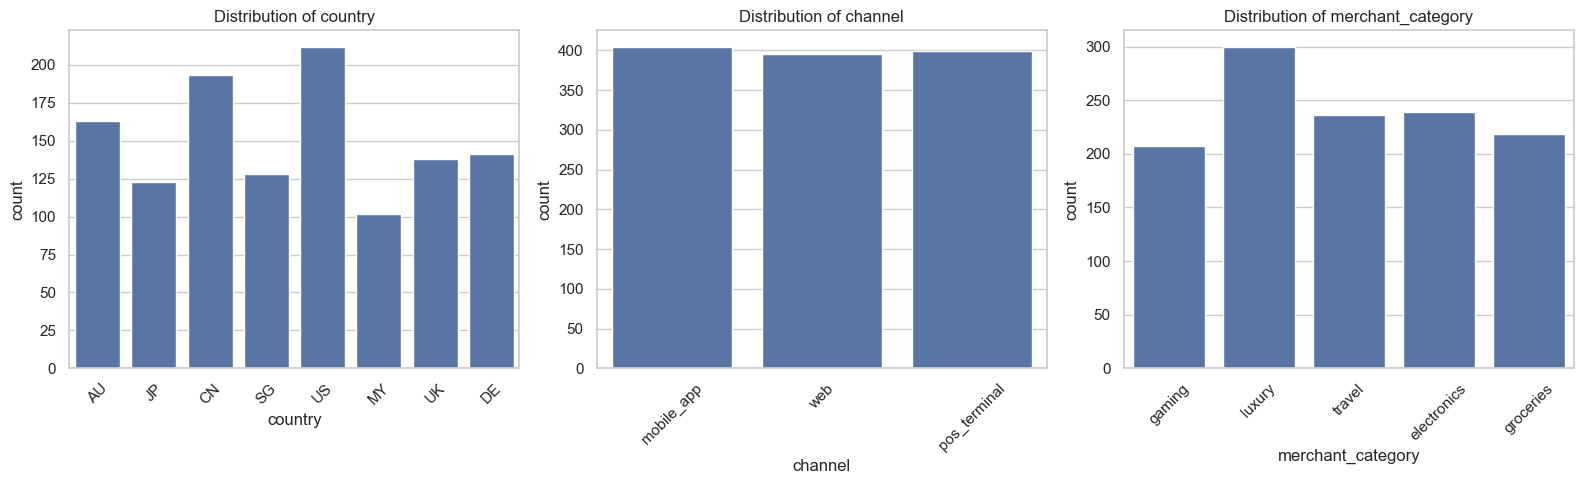

In [166]:
plt.figure(figsize=(16, 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Boxplots by Fraud Status

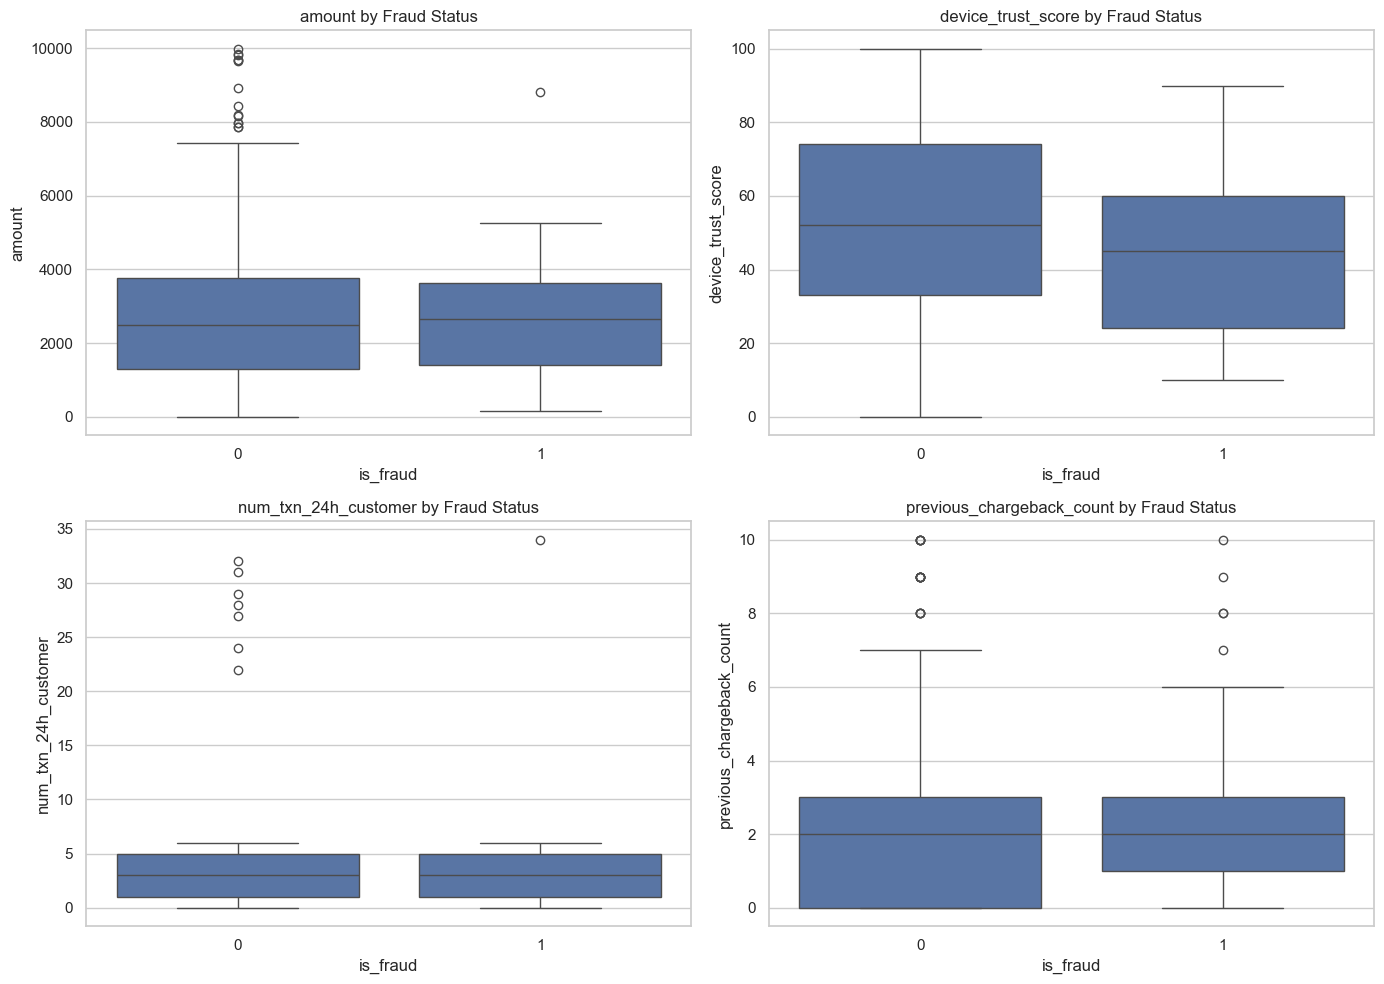

In [167]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="is_fraud", y=col)
    plt.title(f"{col} by Fraud Status")

plt.tight_layout()
plt.show()


Fraud Rate by Categorical Features

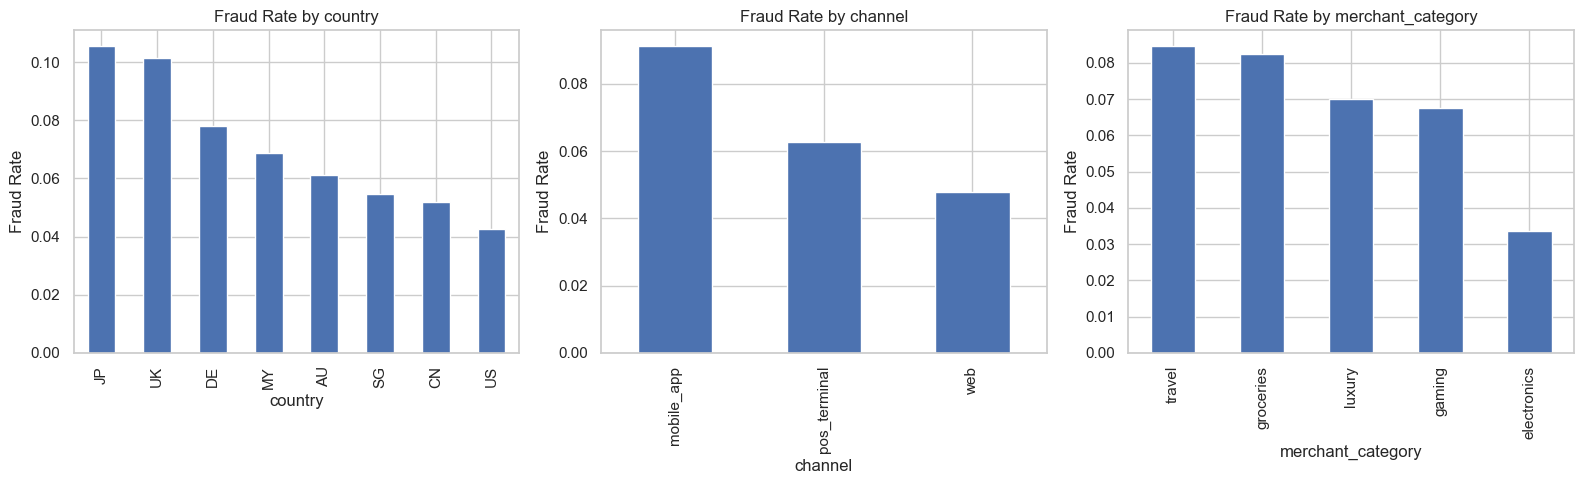

In [168]:
plt.figure(figsize=(16, 5))

for i, col in enumerate(categorical_cols, 1):
    fraud_rate = (
        df.groupby(col)["is_fraud"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.subplot(1, 3, i)
    fraud_rate.plot(kind="bar")
    plt.title(f"Fraud Rate by {col}")
    plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()
